<a href="https://colab.research.google.com/github/rociocelestial/Challenge3-Data-Science/blob/main/TelecomX_parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🛠️ Preparación de los Datos

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Realizando la lectura de los datos

In [ ]:
datos = pd.read_csv('/content/datos_tratados.csv')
datos.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [ ]:
datos.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


🛠️ Pre procesamiento

* Eliminación de Columnas Irrelevantes : que no van influir en nuestro modelo

In [ ]:
datos = datos.drop(columns=['CustomerID'])

In [ ]:
datos

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,No,No,No,13,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


Cambiamos 'No internet service' a 'No' para que no tengan una alta tasa de correlación

In [ ]:

cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    datos[col] = datos[col].replace({'No internet service': 'No'})


Verificando los datos Nulos

In [ ]:
datos.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


#Exploración del análisis de datos

1.- Correlación entre variables numérica

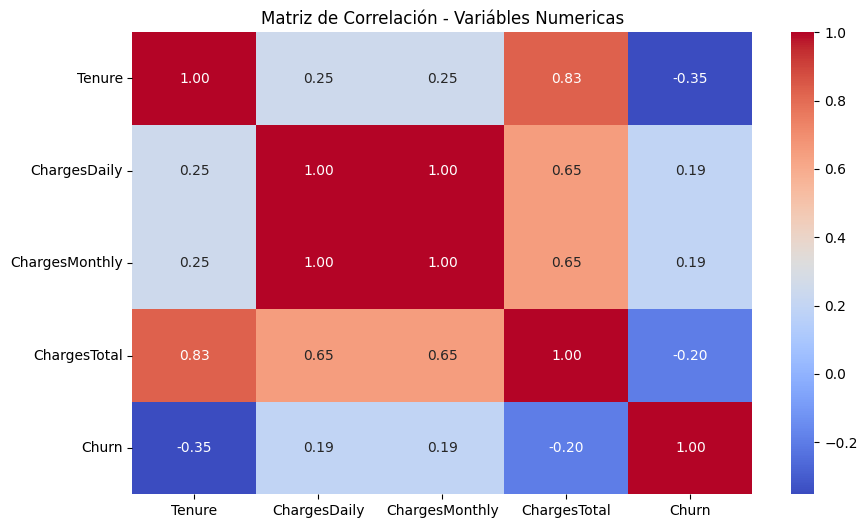

In [ ]:
datos_numeric = datos.select_dtypes(include=["int64", "float64"])

datos_numeric["Churn"] = datos["Churn"].map({"Yes": 1, "No": 0})

corr_matrix = datos_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()


En esta visualización de la correlación de las variables numéricas nos damos cuenta que existe un correlación alta entre :                     

* 'ChargesDaily' y 'ChargesMonthy', porque son lo mismo, ya que 'ChargesDaily' es la división de 'ChargesMontly entre 30, entonces procedemos a eliminar 'CharlesDaily'

Otra que tiene una correlación alta de 0.83 es:

* 'Tenure' y 'ChargesTotal', aqui procederemos a eliminar 'ChargeTotal' porque ella mantiene una correlación mas elevada con las demas variables que 'Tenure'

In [ ]:
datos = datos.drop(columns=['ChargesDaily','ChargesTotal'])

2.- Análisis de Churn por Categorías (variables Categóricas)

Aplicamos el Metodo Chi - square test: para determinar cuales son las variables categóricas significativas

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia
datos_tab = datos.copy()

# Convertir Churn para binario
datos_tab["Churn"] = datos_tab["Churn"].map({"Yes": 1, "No": 0})

# Separar variables categóricas
categorica_column = datos_tab.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categorica_column:
    datos_tab[col] = le.fit_transform(datos_tab[col])

# Separar X e y
X_cat = datos_tab[categorica_column]
y = datos_tab["Churn"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_datos = pd.DataFrame({
    "Variable": categorica_column,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_datos = chi_datos.sort_values(by="Chi2 Score", ascending=False)

chi_datos


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


Tabla de las Variables Significativas

In [ ]:
significant_vars = chi_datos[chi_datos["p-value"] < 0.05]

print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)



✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


Esta tabla me indica que las variables Categóricas no significativas son 'Gender' y 'PhoneService', las cuales procedere a eliminar.

In [ ]:
datos = datos.drop(columns=['Gender','PhoneService'])

1. Tiempo de contrato vs. Cancelación (Boxplot)

El boxplot es ideal aquí porque te permitirá ver si los clientes que cancelan suelen tener contratos más cortos que los que se quedan.

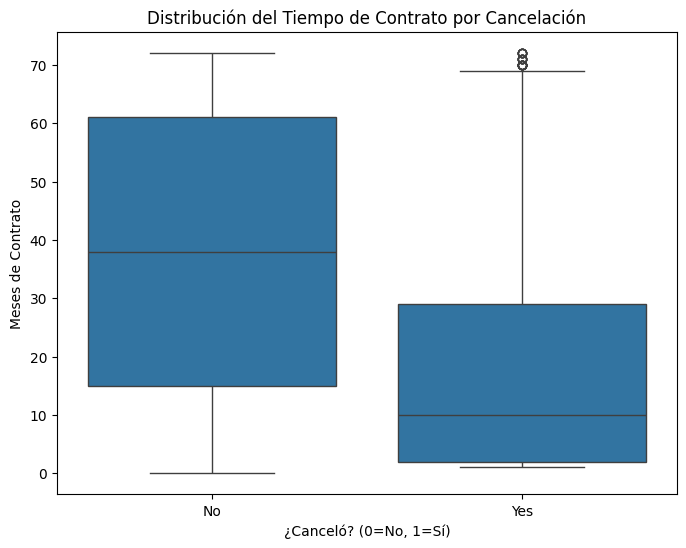

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# 'Churn' es tu columna objetivo y 'Tenure' o 'Tiempo_Contrato' tu variable
sns.boxplot(x='Churn', y='Tenure', data=datos)
plt.title('Distribución del Tiempo de Contrato por Cancelación')
plt.xlabel('¿Canceló? (0=No, 1=Sí)')
plt.ylabel('Meses de Contrato')
plt.show()

2. Gasto Total vs. Cancelación (Boxplot o Histograma)

Para analizar el gasto, un boxplot te mostrará valores atípicos (outliers), mientras que un gráfico de densidad (kdeplot) te mostrará dónde se concentra la mayoría de los pagos.

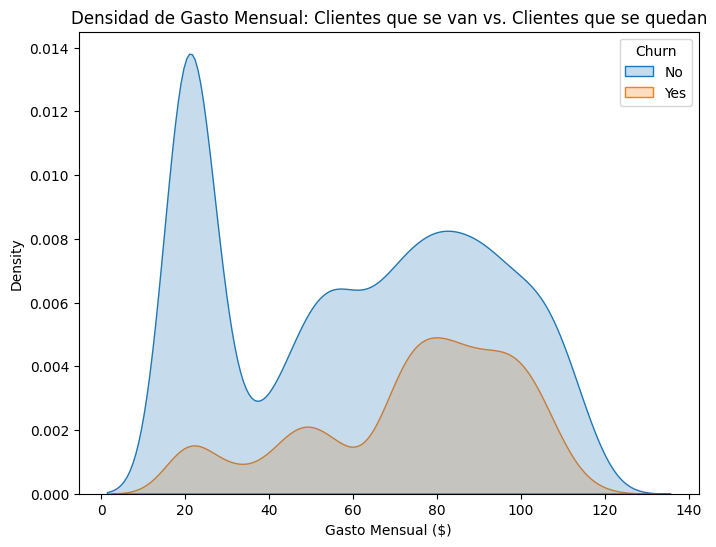

In [ ]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=datos, x='ChargesMonthly', hue='Churn', fill=True)
plt.title('Densidad de Gasto Mensual: Clientes que se van vs. Clientes que se quedan')
plt.xlabel('Gasto Mensual ($)')
plt.show()

3. Relación entre Tiempo y Gasto (Scatter Plot)

El scatter plot es útil para ver si existe una correlación. Podemos usar el color (hue) para diferenciar quiénes cancelaron.

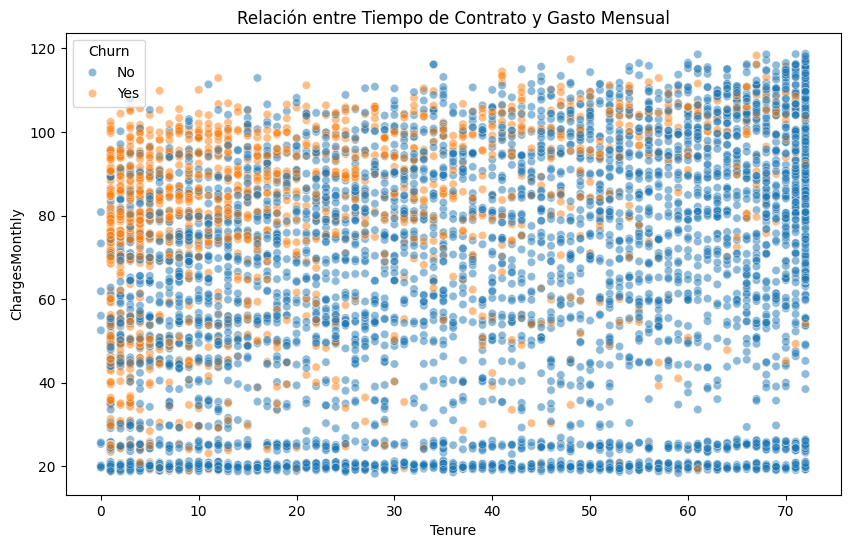

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Tenure', y='ChargesMonthly', hue='Churn', data=datos, alpha=0.5)
plt.title('Relación entre Tiempo de Contrato y Gasto Mensual')
plt.show()

#Separo las Variables Explicativas y la Variable Respuesta

In [ ]:
X = datos.drop ('Churn', axis=1)
y = datos ['Churn']

In [ ]:
X

,SeniorCitizen,Partner,Dependents,Tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,Yes,Yes,9,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,No,No,No,9,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,No,No,No,4,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,Yes,Yes,No,13,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,Yes,Yes,No,3,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,No,No,13,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7039,No,Yes,No,22,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7040,No,No,No,2,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7041,No,Yes,Yes,67,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


Ajustando el modelo

Separando los datos para Entrenamiento y Prueba



In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)

Transformando las Variables Explicativas

In [ ]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
columnas = X.columns

In [ ]:
one_hot = make_column_transformer((OneHotEncoder(drop='if_binary'),['SeniorCitizen','Partner','Dependents','MultipleLines','InternetService',
                                  'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV',
                                  'StreamingMovies','Contract','PaperlessBilling','PaymentMethod']),
                                  remainder='passthrough',
                                  sparse_threshold=0,
                                  force_int_remainder_cols=False)

In [ ]:
# Transformar X_train y X_test usando el transformer 'one_hot'.
# 'fit_transform' se usa en el conjunto de entrenamiento para aprender los encodings y aplicarlos.
# 'transform' se usa en el conjunto de prueba, aplicando los encodings aprendidos del entrenamiento.
X_train = one_hot.fit_transform(X_train)
X_test = one_hot.transform(X_test)


In [ ]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__SeniorCitizen_Yes', 'onehotencoder__Partner_Yes',
       'onehotencoder__Dependents_Yes',
       'onehotencoder__MultipleLines_Yes',
       'onehotencoder__InternetService_DSL',
       'onehotencoder__InternetService_Fiber optic',
       'onehotencoder__InternetService_No',
       'onehotencoder__OnlineSecurity_Yes',
       'onehotencoder__OnlineBackup_Yes',
       'onehotencoder__DeviceProtection_Yes',
       'onehotencoder__TechSupport_Yes', 'onehotencoder__StreamingTV_Yes',
       'onehotencoder__StreamingMovies_Yes',
       'onehotencoder__Contract_Month-to-month',
       'onehotencoder__Contract_One year',
       'onehotencoder__Contract_Two year',
       'onehotencoder__PaperlessBilling_Yes',
       'onehotencoder__PaymentMethod_Bank transfer (automatic)',
       'onehotencoder__PaymentMethod_Credit card (automatic)',
       'onehotencoder__PaymentMethod_Electronic check',
       'onehotencoder__PaymentMethod_Mailed check', 'remainder__Tenure',
       'rema

In [ ]:
pd.DataFrame(X, columns = one_hot.get_feature_names_out(columnas) ).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   onehotencoder__SeniorCitizen_Yes                        0 non-null      float64
 1   onehotencoder__Partner_Yes                              0 non-null      float64
 2   onehotencoder__Dependents_Yes                           0 non-null      float64
 3   onehotencoder__MultipleLines_Yes                        0 non-null      float64
 4   onehotencoder__InternetService_DSL                      0 non-null      float64
 5   onehotencoder__InternetService_Fiber optic              0 non-null      float64
 6   onehotencoder__InternetService_No                       0 non-null      float64
 7   onehotencoder__OnlineSecurity_Yes                       0 non-null      float64
 8   onehotencoder__OnlineBackup_Yes       

Transformando la Variable Respuesta

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()

In [ ]:
y = label_encoder.fit_transform(y)

In [ ]:
y

array([0, 0, 1, ..., 0, 0, 0])

Verificando el Desbalance

In [ ]:
y_train.value_counts(normalize=True)*100

,proportion
Churn,
No,73.464679
Yes,26.535321


Modelo de referencia: Baseline

In [ ]:
from sklearn.dummy import DummyClassifier

In [ ]:
dummy = DummyClassifier()
dummy.fit(X_train,y_train)

dummy.score(X_test,y_test)

0.7345635202271115

Normalizando los datos

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Ahora que X_train y X_test ya están transformados (con OneHotEncoder) y son numéricos,
# podemos aplicar MinMaxScaler para normalizar los datos.
normalizacion = MinMaxScaler()
X_train_normalizado = normalizacion.fit_transform(X_train)
X_test_normalizado = normalizacion.transform(X_test)

In [ ]:
pd.DataFrame(X_train_normalizado, columns = one_hot.get_feature_names_out(columnas) )


,onehotencoder__SeniorCitizen_Yes,onehotencoder__Partner_Yes,onehotencoder__Dependents_Yes,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__OnlineSecurity_Yes,onehotencoder__OnlineBackup_Yes,onehotencoder__DeviceProtection_Yes,...,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaperlessBilling_Yes,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,remainder__Tenure,remainder__ChargesMonthly
0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.833333,0.754360
1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.166667,0.009467
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.027778,0.618336
3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.458333,0.561535
4,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.194444,0.673642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.305556,0.023418
5630,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.583333,0.755356
5631,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.277778,0.666168
5632,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.333333,0.062780


##Creación de Modelos

**Modelo 1 : Regresión Lineal**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

modelo_regresion_lineal = LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)
modelo_regresion_lineal.fit(X_train,y_train)

y_pred_regresion_lineal = modelo_regresion_lineal.predict(X_test)

print(classification_report(y_test,y_pred_regresion_lineal))

              precision    recall  f1-score   support

          No       0.91      0.73      0.81      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



###**Evaluando el modelo**

In [ ]:
modelo_regresion_lineal.score(X_train,y_train)

0.7522186723464679

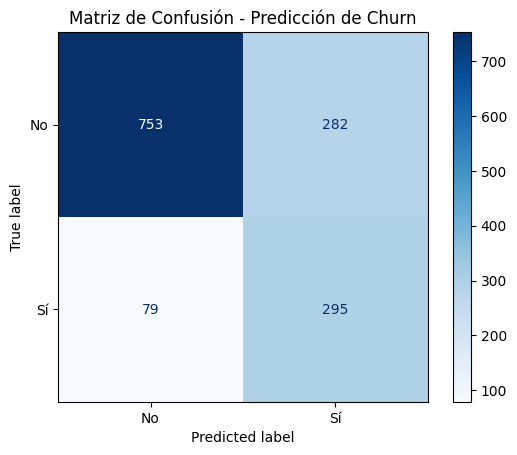

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generar la matriz numérica
cm = confusion_matrix(y_test, y_pred_regresion_lineal)

# 2. Configurar la visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])

# 3. Graficar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Predicción de Churn")
plt.show()

**Modelo 2 : Decisión Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

modelo_arbol = DecisionTreeClassifier(class_weight='balanced',max_depth=3,random_state=42)
modelo_arbol.fit(X_train,y_train)

y_pred_modelo_arbol = modelo_arbol.predict(X_test)


print(classification_report(y_test,y_pred_modelo_arbol))


              precision    recall  f1-score   support

          No       0.90      0.74      0.81      1035
         Yes       0.51      0.77      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409



###**Evaluando el modelo**

In [ ]:
modelo_arbol.score(X_train,y_train)

0.7451189208377706

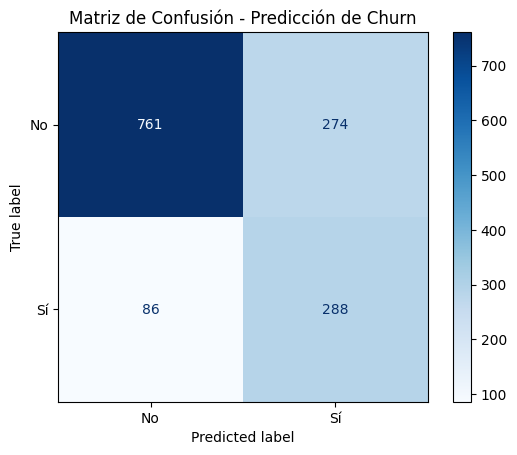

In [ ]:
# 1. Generar la matriz numérica
cm = confusion_matrix(y_test, y_pred_modelo_arbol)

# 2. Configurar la visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])

# 3. Graficar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Predicción de Churn")
plt.show()

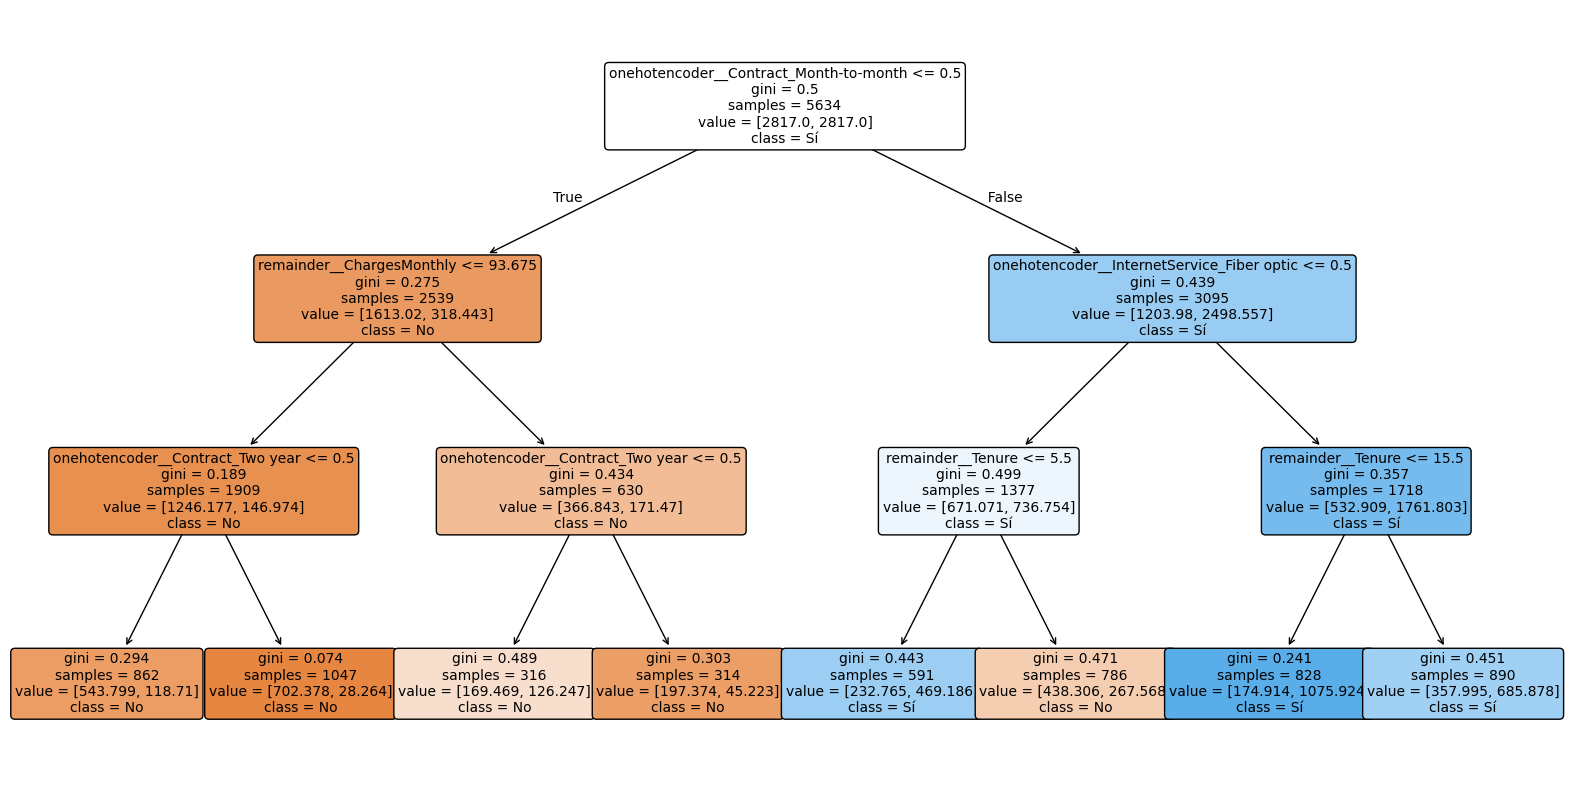

In [ ]:
import sklearn.tree as tree
plt.figure(figsize=(20,10))
tree.plot_tree(modelo_arbol,
               feature_names=one_hot.get_feature_names_out(columnas),
               class_names=['No', 'Sí'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.show()

**Modelo 3 : Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


modelo_random_forest = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)
modelo_random_forest.fit(X_train,y_train)

y_pred_modelo_random_forest = modelo_random_forest.predict(X_test)


print(classification_report(y_test,y_pred_modelo_random_forest))


              precision    recall  f1-score   support

          No       0.82      0.89      0.85      1035
         Yes       0.60      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409



###**Evaluando el modelo**

In [ ]:
modelo_random_forest.score(X_train,y_train)

0.9966276180333689

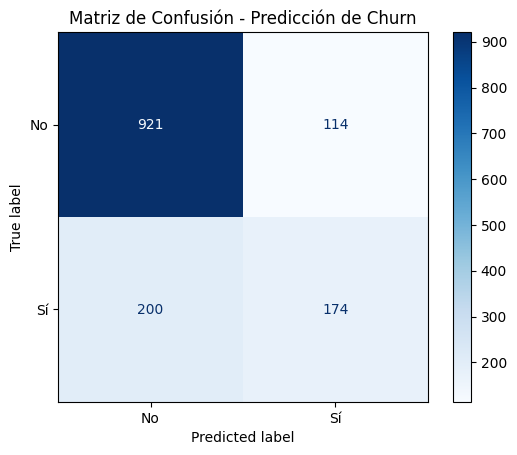

In [ ]:
# 1. Generar la matriz numérica
cm = confusion_matrix(y_test, y_pred_modelo_random_forest)

# 2. Configurar la visualización
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Sí'])

# 3. Graficar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Predicción de Churn")
plt.show()

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Asumiendo que tus modelos ya están entrenados (fit)
# y tus variables están en 'X_train.columns'

def graficar_importancia(modelo, titulo, features):
    if hasattr(modelo, 'coef_'): # Para Regresión Logística
        importancias = modelo.coef_[0]
    else: # Para Árboles y Random Forest
        importancias = modelo.feature_importances_

    feat_importances = pd.Series(importancias, index=features)
    feat_importances.nlargest(10).plot(kind='barh', color='skyblue')
    plt.title(titulo)
    plt.show()

# Uso:
# graficar_importancia(log_reg, "Top 10 - Regresión Logística", X_train.columns)
# graficar_importancia(dec_tree, "Top 10 - Decision Tree", X_train.columns)
# graficar_importancia(rf_model, "Top 10 - Random Forest", X_train.columns)

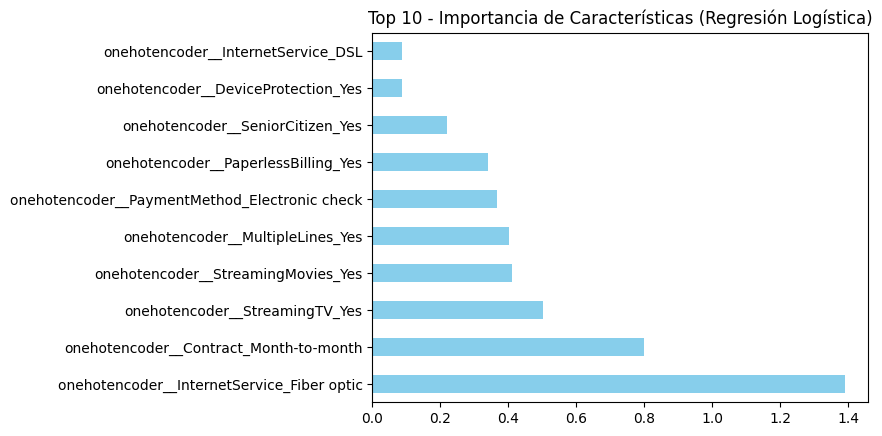

In [ ]:
feature_names = one_hot.get_feature_names_out(columnas)

# Graficar importancia para Regresión Logística
graficar_importancia(modelo_regresion_lineal, "Top 10 - Importancia de Características (Regresión Logística)", feature_names)

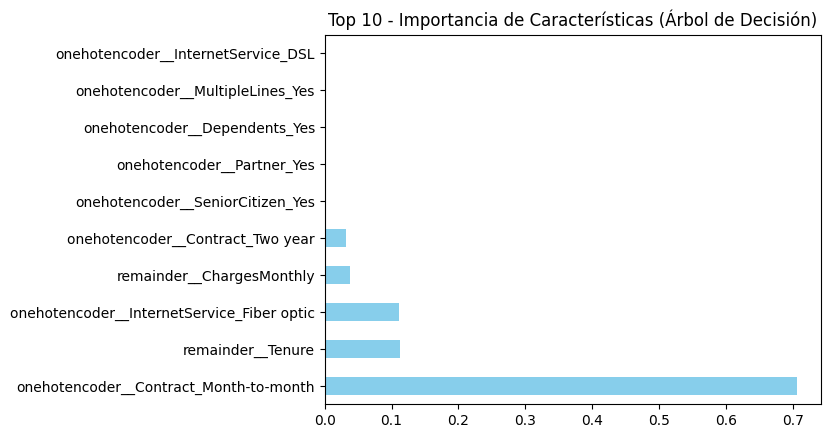

In [ ]:
feature_names = one_hot.get_feature_names_out(columnas)

# Graficar importancia para Árbol de Decisión
graficar_importancia(modelo_arbol, "Top 10 - Importancia de Características (Árbol de Decisión)", feature_names)

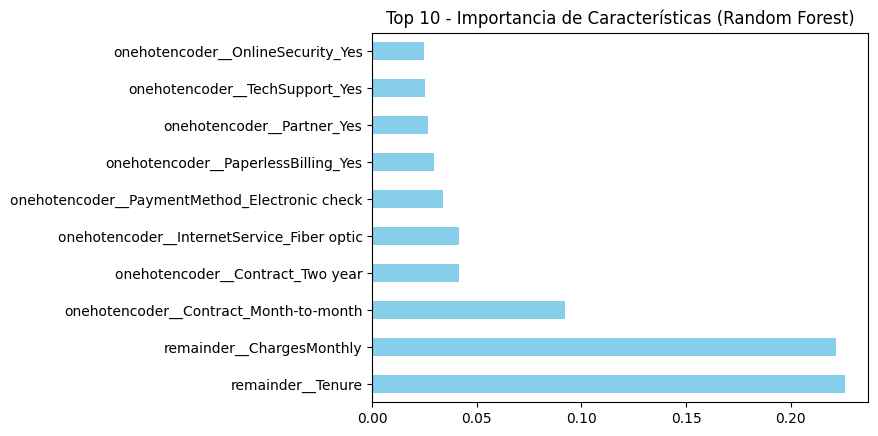

In [ ]:
feature_names = one_hot.get_feature_names_out(columnas)

# Graficar importancia para Random Forest
graficar_importancia(modelo_random_forest, "Top 10 - Importancia de Características (Random Forest)", feature_names)

#📋 Interpretación y Conclusiones

**Análisis de la Importancia de las Variables**

# Informe de Resultados: Análisis de Predictores de Churn (TelecomX)

---

## I. Análisis Detallado de Importancia de las Variables

A continuación, se detalla la interpretación de los tres gráficos generados para entender qué factores pesan más en cada modelo:

### 1. Regresión Logística (Coeficientes)
Este modelo analiza la relación directa y lineal entre las variables.

* **Variable dominante:** `InternetService_Fiber optic`. Es, por mucho, el factor con mayor peso. En este modelo, el uso de fibra óptica tiene una correlación muy fuerte con la predicción de fuga.
* **Otros factores clave:** El contrato `Month-to-month` y el servicio de `Streaming TV` también influyen considerablemente.
* **Interpretación:** El modelo identifica que ciertos servicios técnicos y la modalidad de pago mensual son los indicadores más claros para clasificar a los clientes.

### 2. Árbol de Decisión (Feature Importance)
Los árboles de decisión tienden a jerarquizar la información de manera drástica para simplificar la toma de decisiones.

* **Variable dominante:** `Contract_Month-to-month`. El modelo le asigna casi todo el peso (aproximadamente 0.7).
* **Variables secundarias:** La antigüedad del cliente (`Tenure`) y la fibra óptica tienen una importancia mínima en comparación.
* **Interpretación:** Para este modelo, el tipo de contrato es el factor decisivo; si es "mes a mes", el árbol obtiene casi toda la información necesaria para predecir el comportamiento.

### 3. Random Forest (Feature Importance)
Al ser un conjunto de múltiples árboles, este modelo ofrece la visión más equilibrada y robusta de los datos.

* **Variables dominantes:** `Tenure` (antigüedad) y `ChargesMonthly` (cargos mensuales). Ambas están prácticamente empatadas como las más importantes.
* **Factor de contrato:** El contrato `Month-to-month` aparece en tercer lugar, seguido de la fibra óptica.
* **Interpretación:** Este modelo es más "holístico". Nos indica que el comportamiento del cliente está definido principalmente por cuánto tiempo lleva en la empresa y cuánto paga, además de la flexibilidad de su contrato.

---

## Conclusión General del Análisis

Al comparar los tres modelos, se observa un patrón consistente que define la fuga de clientes:

* **El contrato "Month-to-month" es crítico en todos los casos.** La falta de permanencia es el mayor riesgo de abandono.
* **La Fibra Óptica es un punto de fricción constante**, lo que sugiere posibles áreas de mejora en precio o calidad de este servicio específico.
* **La Antigüedad (Tenure) se consolida como el mejor predictor de lealtad** en los modelos más complejos, indicando que el riesgo disminuye conforme el cliente suma tiempo en la compañía.

---

## II. Interpretación y Conclusiones: Análisis de Predictores de Churn

Este informe evalúa tres algoritmos de aprendizaje supervisado frente a un modelo de referencia (**Dummy**) para identificar el mejor predictor de abandono de clientes.

### 1. Contexto del Dataset
El dataset presenta un desbalanceo de clases significativo que debemos considerar:

* **Churn (No):** 73% (5,163 registros)
* **Churn (Si):** 26% (1,869 registros)

> **Nota sobre el desbalanceo:** Cualquier modelo que simplemente prediga "No" todo el tiempo tendrá un 73% de exactitud (Accuracy), pero fallará completamente en el objetivo del negocio: detectar a los clientes que sí se van.

### 2. Comparativa de Métricas (Clase "Yes" / Churn)

| Modelo | Recall (Sensibilidad) | Precision | F1-Score | Accuracy (Prueba) | Score (Entrenamiento) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| DummyClassifier | 0.00 | 0.00 | 0.00 | 0.7345 | 0.7345 |
| **Regresión Logística** | **0.79** | 0.51 | 0.62 | 0.7445 | 0.7522 |
| Árbol de Decisión | 0.77 | 0.51 | 0.62 | 0.7451 | 0.7451 |
| Random Forest | 0.47 | 0.60 | 0.53 | 0.7814 | 0.9966 |

### 3. Análisis Individual de Modelos

* **A. DummyClassifier (Línea Base):** Es el modelo de control. Al predecir siempre la clase mayoritaria, obtiene un 73% de exactitud pero un 0% de Recall. No detecta a ningún cliente en riesgo.
* **B. Regresión Logística (Modelo Ganador):** Logra el Recall más alto (0.79). Identifica a casi 8 de cada 10 clientes que se darán de baja. Es el que menos clientes "deja escapar", prioridad económica de la empresa.
* **C. Árbol de Decisión (Modelo de Interpretación):** Sus métricas son casi tan buenas como la regresión logística (Recall 0.77). Permite visualizar reglas de negocio claras y es muy estable entre entrenamiento y prueba.
* **D. Random Forest (Sobreajustado):** Aunque tiene el Accuracy más alto en prueba (0.78), su score de entrenamiento de 0.9966 indica que ha memorizado los datos (**Overfitting**). Solo detecta al 47% de los clientes en riesgo.

### 4. Conclusión y Recomendación
Para la empresa de telecomunicaciones, el modelo recomendado es la **Regresión Logística**.

**Justificación:** En un escenario de Churn, el costo de perder a un cliente (Falso Negativo) es mucho mayor al costo de ofrecer una promoción a quien no pensaba irse (Falso Positivo). La Regresión Logística es el modelo que mejor minimiza esos errores críticos y presenta un rendimiento generalizable y honesto.

---

## 5. Interpretación del Árbol de Decisión: ¿Por qué se van los clientes?

El gráfico generado con `tree.plot_tree` nos permite entender qué variables son las más importantes:

* **La Raíz (Nodo Superior):** Es la variable más importante. El primer filtro es el tipo de contrato (`Contract_Month-to-month`). Si el cliente tiene contrato mes a mes, el riesgo de churn aumenta inmediatamente.
* **Las Ramas (True / False):** Si la condición se cumple, el árbol baja hacia la izquierda; si no, hacia la derecha.
* **Nodos de Decisión:** Por ejemplo, el nodo de `ChargesMonthly <= 93.675` indica que el monto de la factura mensual es el disparador final.
* **Gini (Impureza):** Cuanto más bajo es el índice Gini (cercano a 0), más "pura" es la decisión en ese nodo.

### Hallazgos Clave para el Negocio:
* **El Contrato es el factor #1:** Los clientes con contratos anuales o bianuales tienen un riesgo de abandono casi nulo comparado con los de mes a mes.
* **Sensibilidad al Precio:** El modelo identifica un umbral crítico de cargos mensuales. Superar los **$93.67** mensuales hace que el cliente sea mucho más propenso a buscar otra compañía.

> **Impacto Estratégico:** Recomendamos a la empresa enfocar sus campañas de fidelización en convertir a los clientes de "mes a mes" a contratos de "un año", o revisar la competitividad de sus precios cuando la factura supera los $93.


## III.- Análisis Comparativo de Matrices de Confusión

A continuación se presenta el análisis de los tres modelos de clasificación implementados para la predicción de fuga de clientes (*Churn*).

### 1. Regresión Logística
**Métricas observadas:** * **Verdaderos Negativos (VN):** 753
* **Falsos Positivos (FP):** 282
* **Falsos Negativos (FN):** 79
* **Verdaderos Positivos (VP):** 295

**Interpretación:**
* Es el modelo con **mayor capacidad de detección (Recall)**, ya que solo dejó pasar a 79 clientes que realmente se fugaron.
* **Debilidad:** Tiene un alto volumen de falsos positivos, lo que implicaría un gasto innecesario en campañas de retención para clientes que no pensaban irse.

---

### 2. Decision Tree (Árbol de Decisión)
**Métricas observadas:** * **Verdaderos Negativos (VN):** 761
* **Falsos Positivos (FP):** 274
* **Falsos Negativos (FN):** 86
* **Verdaderos Positivos (VP):** 288

**Interpretación:**
* Muestra un desempeño equilibrado, muy similar a la Regresión Logística pero con una ligera disminución en la detección de positivos (86 omisiones frente a 79).
* Es un modelo útil para entender las reglas de negocio, pero menos estable que los demás.

---

### 3. Random Forest
**Métricas observadas:** * **Verdaderos Negativos (VN):** 921
* **Falsos Positivos (FP):** 114
* **Falsos Negativos (FN):** 200
* **Verdaderos Positivos (VP):** 174

**Interpretación:**
* Es el modelo más **preciso** para identificar a los clientes leales (solo 114 errores).
* **Debilidad Crítica:** Tiene el mayor número de Falsos Negativos (200). En el contexto de TelecomX, esto es riesgoso porque el modelo no logra identificar a más de la mitad de los clientes que están en riesgo real de abandonar la compañía.

---

### Conclusión Final del Comparativo de Matrices de Confusión

Para el caso de **TelecomX**, si el objetivo principal es **reducir la pérdida de clientes**, el modelo de **Regresión Logística** es el más adecuado debido a su bajo índice de Falsos Negativos. Si el objetivo es optimizar el presupuesto de marketing y evitar molestar a clientes leales, **Random Forest** sería la opción preferida.

---


# 📊 Conclusión Final y Estrategias

## 📌 Conclusión del Análisis de Datos
Tras un análisis exhaustivo de los modelos de Machine Learning, se concluye que la retención en **TelecomX** no depende de un solo factor, sino de la combinación de estabilidad contractual, precios competitivos y calidad de servicio.

* **El Modelo Ganador:** Se seleccionó la **Regresión Logística** por su alto **Recall (0.79)**. Esto significa que el modelo es capaz de identificar correctamente a **8 de cada 10 clientes** que están en riesgo real de fuga.
* **Impacto Económico:** Es mucho más rentable asumir el costo de una promoción para un cliente leal (Falso Positivo) que perder por completo el valor de vida de un cliente que se va a la competencia (Falso Negativo).
* **Estado Actual:** Con una tasa de abandono del **26%**, el modelo nos permite pasar de una postura reactiva (esperar a que el cliente cancele) a una **proactiva** (actuar antes de que se vaya).

La clave no es solo saber quién se va, sino por qué: los contratos mensuales, las facturas que superan los $93.67 y los problemas percibidos en la fibra óptica son los detonantes principales.

---

## 🚀 Estrategias de Mitigación (Plan de Acción)

Basándonos en los predictores clave identificados (**Tipo de Contrato, Cargos Mensuales y Fibra Óptica**), se proponen las siguientes tres rutas de acción inmediata:

### 1. Programa de Migración Contractual
El contrato "mes a mes" es el mayor predictor de fuga. Necesitamos mover a los clientes hacia la estabilidad.
* **Acción:** Incentivar el paso de planes mensuales a contratos anuales o bianuales.
* **Táctica:** Ofrecer un **"Mes de Lealtad"** gratuito o descuentos progresivos a quienes acepten un compromiso de permanencia de 12 meses.

### 2. Optimización de la Oferta de Fibra Óptica
Se detectó un punto de fricción crítico: clientes con Fibra Óptica y facturas que superan los **$93.67**.
* **Acción:** Crear un **"Escuadrón de Retención"** para gestionar proactivamente a los clientes de alto gasto.
* **Táctica:** Si un usuario de fibra alcanza este umbral de precio, el sistema debe alertar al equipo de atención para ofrecerle un paquete de beneficios o un plan optimizado antes de que surja la insatisfacción.

### 3. Plan de Blindaje para Clientes Nuevos (*Tenure*)
El riesgo de fuga es máximo durante los primeros 6 meses. Si el cliente supera este periodo, su lealtad aumenta drásticamente.
* **Acción:** Implementar un **"Plan de Bienvenida Reforzado"**.
* **Táctica:** Ofrecer beneficios que crezcan con el tiempo (ej. aumento de velocidad de internet sin costo a partir del mes 7) para consolidar la lealtad en la etapa más vulnerable.

---

> **Nota Estratégica:** Integrar estas predicciones directamente en el CRM permitirá que las llamadas de clientes en **"Alto Riesgo"** sean atendidas por agentes senior con capacidad de ofrecer soluciones inmediatas, transformando los datos en rentabilidad real.